# TinyML Motion Detection — Phone Accelerometer to Embedded C Model

An end-to-end Edge AI pipeline: real phone accelerometer data → automatic Idle/Motion labeling → sliding-window feature extraction → a compact Keras MLP → INT8 quantization → a portable C header ready for microcontroller deployment (ESP32 / Arduino / STM32).

**Pipeline**
`Raw CSV (Phyphox)` → `Clean & Auto-Label` → `Sliding-Window Features` → `Train Lightweight MLP` → `INT8 TFLite Quantization` → `C Byte-Array (.h)`

### Step 1 — How the Data Was Collected
Recorded with **Phyphox** (Linear Accelerometer sensor): the phone sat flat and still on a table for the first stretch of the recording (**Idle**), then was picked up and moved around for the rest of it (**Motion**). The session was exported as `Raw_Data.csv`.

Rather than assuming a fixed 50/50 split like a naive approach would, Step 3 below detects the Idle→Motion transition directly from the signal — so this same notebook works on any similarly recorded session, not just one where the split happens to land exactly at the midpoint.

In [10]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # keep TensorFlow's console noise out of the way
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


### Step 2 — Load & Standardize Sensor Columns
Load `Raw_Data.csv` and rename the raw Phyphox headers to simple `accel_x / accel_y / accel_z / accel_mag` columns. If the file isn't already in the Colab session, this falls back to the upload widget automatically.

In [11]:
CSV_NAME = "Raw_Data.csv"

if not os.path.exists(CSV_NAME):
    from google.colab import files
    print(f"'{CSV_NAME}' not found in this session — please upload it.")
    uploaded = files.upload()
    CSV_NAME = next(iter(uploaded))

df = pd.read_csv(CSV_NAME)

column_mapping = {
    "Time (s)": "time",
    "Linear Acceleration x (m/s^2)": "accel_x",
    "Linear Acceleration y (m/s^2)": "accel_y",
    "Linear Acceleration z (m/s^2)": "accel_z",
    "Absolute acceleration (m/s^2)": "accel_mag",
}
df = df.rename(columns=column_mapping)[list(column_mapping.values())].dropna()

print(f"Loaded {len(df)} samples spanning {df['time'].iloc[-1]:.1f}s "
      f"(~{len(df)/df['time'].iloc[-1]:.0f} Hz)")
df.head()

'Raw_Data.csv' not found in this session — please upload it.


Saving Raw Data.csv to Raw Data (1).csv
Loaded 10869 samples spanning 54.7s (~199 Hz)


,time,accel_x,accel_y,accel_z,accel_mag
0,0.045564,0.000000,0.000000,0.000000,0.000000
1,0.050590,-0.018796,-0.004788,0.033512,0.038721
2,0.055558,-0.006021,-0.009543,0.031917,0.033852
3,0.060584,0.020415,-0.017890,-0.026337,0.037821
4,0.065462,-0.006990,0.012545,-0.078524,0.079826


### Step 3 — Auto-Label Idle vs Motion
Smooth the acceleration magnitude with a short rolling window to remove sensor noise, then threshold it. Samples above the threshold are **Motion (1)**, everything else is **Idle (0)**. This data-driven boundary replaces guessing where the transition happened.

In [37]:
WINDOW = 25       # ~0.13s smoothing window at ~200Hz
THRESHOLD = 0.5  # m/s^2 — tuned to give a clean idle/motion border on this recording

df["accel_smooth"] = df["accel_mag"].rolling(WINDOW, center=True, min_periods=1).mean()
df["label"] = (df["accel_smooth"] > THRESHOLD).astype(int)

# Find every contiguous run of the same label, not just the first Idle->Motion switch
segments = []
start_idx = 0
for i in range(1, len(df)):
    if df["label"].iloc[i] != df["label"].iloc[i - 1]:
        segments.append((start_idx, i - 1, df["label"].iloc[start_idx]))
        start_idx = i
segments.append((start_idx, len(df) - 1, df["label"].iloc[start_idx]))

print(f"Idle samples: {(df['label']==0).sum()}  |  Motion samples: {(df['label']==1).sum()}")
print(f"Found {len(segments)} segments:\n")
for start, end, label in segments:
    t_start, t_end = df["time"].iloc[start], df["time"].iloc[end]
    name = "Motion" if label == 1 else "Idle"
    print(f"  {name:6s}  {t_start:6.2f}s -> {t_end:6.2f}s   (duration {t_end - t_start:5.2f}s, {end - start + 1} samples)")

Idle samples: 7411  |  Motion samples: 3458
Found 14 segments:

  Idle      0.05s ->  31.27s   (duration 31.23s, 6214 samples)
  Motion   31.28s ->  31.48s   (duration  0.20s, 41 samples)
  Idle     31.48s ->  35.16s   (duration  3.68s, 733 samples)
  Motion   35.17s ->  35.40s   (duration  0.23s, 47 samples)
  Idle     35.40s ->  37.67s   (duration  2.26s, 451 samples)
  Motion   37.67s ->  37.89s   (duration  0.22s, 45 samples)
  Idle     37.90s ->  37.90s   (duration  0.01s, 2 samples)
  Motion   37.91s ->  38.62s   (duration  0.71s, 142 samples)
  Idle     38.62s ->  38.63s   (duration  0.01s, 3 samples)
  Motion   38.64s ->  54.38s   (duration 15.74s, 3133 samples)
  Idle     54.38s ->  54.40s   (duration  0.02s, 4 samples)
  Motion   54.40s ->  54.52s   (duration  0.12s, 24 samples)
  Idle     54.52s ->  54.54s   (duration  0.02s, 4 samples)
  Motion   54.54s ->  54.67s   (duration  0.13s, 26 samples)


### Step 4 — Visualize the Labeled Signal

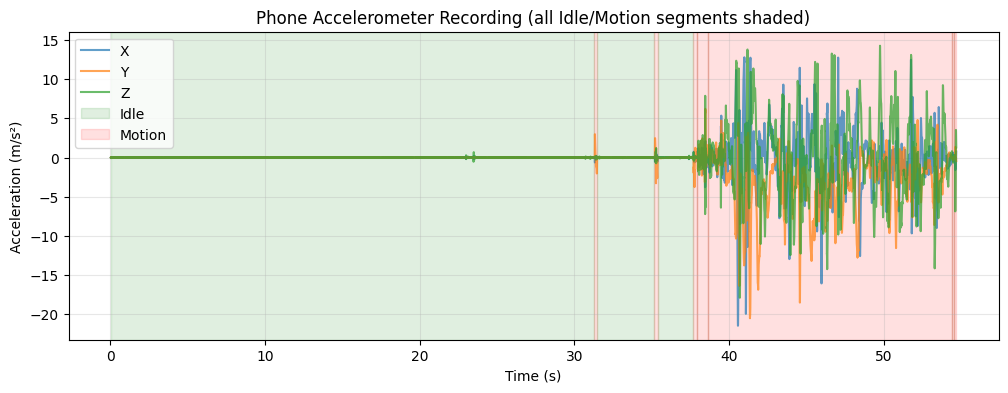

In [38]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["time"], df["accel_x"], label="X", alpha=0.7)
ax.plot(df["time"], df["accel_y"], label="Y", alpha=0.7)
ax.plot(df["time"], df["accel_z"], label="Z", alpha=0.7)

for start, end, label in segments:
    color = "red" if label == 1 else "green"
    ax.axvspan(df["time"].iloc[start], df["time"].iloc[end], color=color, alpha=0.12)

from matplotlib.patches import Patch
region_handles = [Patch(color="green", alpha=0.12, label="Idle"), Patch(color="red", alpha=0.12, label="Motion")]
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles=handles + region_handles)

ax.set(title="Phone Accelerometer Recording (all Idle/Motion segments shaded)",
       xlabel="Time (s)", ylabel="Acceleration (m/s²)")
ax.grid(alpha=0.3)
plt.show()

### Step 5 — Sliding-Window Feature Extraction
Each window becomes one training example: mean and standard deviation of X/Y/Z acceleration over `window_size` samples, stepped forward by `step_size`. This is the same statistical-feature approach microcontrollers use at inference time — cheap enough to run on an 8-bit MCU. A window is labeled by majority vote rather than its last sample, so windows straddling the boundary aren't mislabeled.

In [39]:
def extract_windows(data, window_size=50, step_size=25):
    feats, labels = [], []
    for start in range(0, len(data) - window_size, step_size):
        w = data.iloc[start:start + window_size]
        feats.append([
            w["accel_x"].mean(), w["accel_x"].std(),
            w["accel_y"].mean(), w["accel_y"].std(),
            w["accel_z"].mean(), w["accel_z"].std(),
        ])
        labels.append(int(w["label"].mean() > 0.5))
    return np.array(feats, dtype=np.float32), np.array(labels, dtype=np.int32)

X, y = extract_windows(df)
print(f"Feature matrix: {X.shape}   Idle windows: {(y==0).sum()}   Motion windows: {(y==1).sum()}")

Feature matrix: (433, 6)   Idle windows: 295   Motion windows: 138


### Step 6 — Train/Test Split & Train the Lightweight MLP
A held-out test set (never seen during training) gives an honest accuracy estimate — training accuracy alone doesn't say how well the model generalizes. The network itself stays tiny (8 → 4 → 2 neurons) so it fits comfortably on an MCU.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = models.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(2, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, epochs=35, batch_size=8, verbose=0)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Train accuracy: {history.history['accuracy'][-1]:.2%}")
print(f"Test accuracy:  {test_acc:.2%}")

Train accuracy: 99.71%
Test accuracy:  98.85%


### Step 7 — Quantize to INT8 (TensorFlow Lite)
Compress the FP32 weights/activations to INT8 so the model runs on MCUs without a floating-point unit.

In [41]:
def representative_data_gen():
    for sample in tf.data.Dataset.from_tensor_slices(X_train).batch(1).take(100):
        yield [tf.cast(sample, tf.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

MODEL_FILE = "phone_motion_model.tflite"
with open(MODEL_FILE, "wb") as f:
    f.write(tflite_model)

keras_params = model.count_params()
print(f"Keras model:      {keras_params} parameters (~{keras_params*4} bytes as FP32)")
print(f"Quantized TFLite: {len(tflite_model)} bytes (~{len(tflite_model)/1024:.2f} KB)")

Saved artifact at '/tmp/tmp3h30xzz7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138461588158800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138463976772944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138461588081744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138461588079632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138461588084432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138463776734672: TensorSpec(shape=(), dtype=tf.resource, name=None)
Keras model:      102 parameters (~408 bytes as FP32)
Quantized TFLite: 2904 bytes (~2.84 KB)


### Step 8 — Validate the Quantized Model
Run the *entire* test set through the INT8 interpreter (not just one sample) and compare accuracy against the original Keras model, to confirm quantization didn't hurt accuracy.

In [42]:
interpreter = tf.lite.Interpreter(model_path=MODEL_FILE)
interpreter.allocate_tensors()
in_detail = interpreter.get_input_details()[0]
out_detail = interpreter.get_output_details()[0]
scale, zero_point = in_detail["quantization"]

correct = 0
for sample, true_label in zip(X_test, y_test):
    q_input = (sample / scale + zero_point).astype(np.int8).reshape(1, -1)
    interpreter.set_tensor(in_detail["index"], q_input)
    interpreter.invoke()
    pred = np.argmax(interpreter.get_tensor(out_detail["index"]))
    correct += int(pred == true_label)

print(f"Quantized TFLite test accuracy: {correct/len(y_test):.2%}  ({correct}/{len(y_test)} correct)")

Quantized TFLite test accuracy: 98.85%  (86/87 correct)


### Step 9 — Export to C Byte Array (.h)
A pure-Python export (no `apt-get`/`xxd` dependency, so it works reliably in any Colab runtime) turns the `.tflite` binary into a C header that compiles straight into a TFLM firmware project for ESP32 / Arduino / STM32.

In [43]:
def tflite_to_c_header(tflite_path, header_path, array_name="phone_motion_model"):
    with open(tflite_path, "rb") as f:
        data = f.read()

    hex_bytes = [f"0x{b:02x}" for b in data]
    lines = [f"unsigned char {array_name}[] = {{"]
    for i in range(0, len(hex_bytes), 12):
        lines.append("  " + ", ".join(hex_bytes[i:i + 12]) + ",")
    lines.append("};")
    lines.append(f"unsigned int {array_name}_len = {len(data)};")

    with open(header_path, "w") as f:
        f.write("\n".join(lines))
    return len(data)

HEADER_FILE = "phone_motion_model.h"
n_bytes = tflite_to_c_header(MODEL_FILE, HEADER_FILE)
print(f"Wrote {HEADER_FILE} ({n_bytes} bytes as a C array)\n")

with open(HEADER_FILE) as f:
    print("\n".join(f.readlines()[:6]))

Wrote phone_motion_model.h (2904 bytes as a C array)

unsigned char phone_motion_model[] = {

  0x1c, 0x00, 0x00, 0x00, 0x54, 0x46, 0x4c, 0x33, 0x14, 0x00, 0x20, 0x00,

  0x1c, 0x00, 0x18, 0x00, 0x14, 0x00, 0x10, 0x00, 0x0c, 0x00, 0x00, 0x00,

  0x08, 0x00, 0x04, 0x00, 0x14, 0x00, 0x00, 0x00, 0x1c, 0x00, 0x00, 0x00,

  0x98, 0x00, 0x00, 0x00, 0xf0, 0x00, 0x00, 0x00, 0xa0, 0x02, 0x00, 0x00,

  0xb0, 0x02, 0x00, 0x00, 0xec, 0x0a, 0x00, 0x00, 0x03, 0x00, 0x00, 0x00,

